# TIFF Compression Quality Comparison Analysis

This notebook compares the quality of reconstructed TIFF files after compression using SSIM (Structural Similarity Index) and PSNR (Peak Signal-to-Noise Ratio) metrics. It identifies the worst performing slices and provides comprehensive visualizations of compression quality across all slices.

## Features:
- **Parallel processing** for efficient computation across large TIFF volumes
- **Configurable parameters** for file ID and quality settings
- **Comprehensive quality metrics** including SSIM and PSNR
- **Statistical analysis** with detailed quality statistics
- **Visual comparison** of worst performing slices with difference maps
- **Quality trends** showing SSIM/PSNR vs slice number
- **Export capabilities** for results and detailed reports

## 1. Import Required Libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import time
from pathlib import Path
from PIL import Image
import tifffile
from typing import List, Tuple, Dict, Any
import multiprocessing as mp
from concurrent.futures import ThreadPoolExecutor
from tqdm.auto import tqdm
import warnings

# Image quality metrics
import cv2
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

# Configure matplotlib for better plots
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['image.cmap'] = 'gray'
plt.rcParams['font.size'] = 12

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore', category=UserWarning)

print("✅ Libraries imported successfully!")
print(f"📊 Available CPU cores: {mp.cpu_count()}")
print("🔍 Quality metrics available:")
print("   - SSIM (Structural Similarity Index)")
print("   - PSNR (Peak Signal-to-Noise Ratio)")
print("🚀 Parallel processing utilities loaded (thread-based by default)")

✅ Libraries imported successfully!
📊 Available CPU cores: 10
🔍 Quality metrics available:
   - SSIM (Structural Similarity Index)
   - PSNR (Peak Signal-to-Noise Ratio)
🚀 Parallel processing utilities loaded (thread-based by default)


## 2. Define Comparison Parameters and Setup

In [ ]:
# =============================================================================
# CONFIGURATION PARAMETERS
# =============================================================================

# Dataset configuration - Modify these parameters for different comparisons
FILE_ID = 10                    # File ID to compare (e.g., 2 for file_2)
QUALITY = 95                   # Compression quality level (e.g., 95)

# Path configuration
BASE_DATA_PATH = Path('../data/ct_files')
ORIGINAL_PATH = BASE_DATA_PATH / f'file_{FILE_ID}_extracted'
COMPRESSED_PATH = BASE_DATA_PATH / f'file_{FILE_ID}_compressed_{QUALITY}'

# Processing configuration
PARALLEL_BACKEND = "thread"        # Options: "thread" (default) or "process"
MAX_WORKERS = max(1, min(mp.cpu_count() - 1, 8))  # Leave one core free, max 8 workers
BATCH_SIZE = 1000                        # Number of files to process per batch
CHUNK_SIZE = 50                        # Chunk size for multiprocessing (process backend only)
USE_PROCESS_POOL = PARALLEL_BACKEND.lower() == "process"

# Analysis configuration
NUM_WORST_SLICES = 10          # Number of worst slices to analyze in detail
DIFFERENCE_THRESHOLD = 0.1     # Threshold for significant differences in visualization

# Output configuration
OUTPUT_DIR = Path(f'comparison_results/file_{FILE_ID}_q{QUALITY}')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"🔧 Configuration Setup:")
print(f"   File ID: {FILE_ID}")
print(f"   Quality: {QUALITY}")
print(f"   Original path: {ORIGINAL_PATH}")
print(f"   Compressed path: {COMPRESSED_PATH}")
print(f"   Parallel backend: {PARALLEL_BACKEND}")
print(f"   Max workers: {MAX_WORKERS}")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Output directory: {OUTPUT_DIR}")

# Validate paths
print(f"\n📁 Path Validation:")
print(f"   Original exists: {ORIGINAL_PATH.exists()}")
print(f"   Compressed exists: {COMPRESSED_PATH.exists()}")

if not ORIGINAL_PATH.exists():
    print(f"   ❌ Original path not found: {ORIGINAL_PATH}")
if not COMPRESSED_PATH.exists():
    print(f"   ❌ Compressed path not found: {COMPRESSED_PATH}")
    
if ORIGINAL_PATH.exists() and COMPRESSED_PATH.exists():
    print("   ✅ Both paths found - ready for comparison!")

🔧 Configuration Setup:
   File ID: 2
   Quality: 95
   Original path: ../data/ct_files/file_2_extracted
   Compressed path: ../data/ct_files/file_2_compressed_95
   Parallel backend: thread
   Max workers: 8
   Batch size: 50
   Output directory: comparison_results/file_2_q95

📁 Path Validation:
   Original exists: True
   Compressed exists: True
   ✅ Both paths found - ready for comparison!


## 3. Load TIFF File Sequences for Comparison

In [4]:
def load_tiff_file_lists(original_path: Path, compressed_path: Path) -> Tuple[List[Path], List[Path]]:
    """
    Load and validate TIFF file lists from original and compressed directories.
    
    Args:
        original_path: Path to original TIFF files
        compressed_path: Path to compressed TIFF files
        
    Returns:
        Tuple of (original_files, compressed_files) sorted lists
    """
    # Get TIFF files from both directories
    original_files = sorted(list(original_path.glob('*.tif*')))
    compressed_files = sorted(list(compressed_path.glob('*.tif*')))
    
    print(f"📂 File Discovery:")
    print(f"   Original files: {len(original_files)}")
    print(f"   Compressed files: {len(compressed_files)}")
    
    if len(original_files) == 0:
        raise ValueError(f"No TIFF files found in original path: {original_path}")
    if len(compressed_files) == 0:
        raise ValueError(f"No TIFF files found in compressed path: {compressed_path}")
    
    # Check if file counts match
    if len(original_files) != len(compressed_files):
        print(f"   ⚠️  Warning: File count mismatch!")
        print(f"   Will compare {min(len(original_files), len(compressed_files))} files")
        
        # Truncate to minimum length
        min_len = min(len(original_files), len(compressed_files))
        original_files = original_files[:min_len]
        compressed_files = compressed_files[:min_len]
    
    # Verify file naming correspondence
    original_names = [f.stem for f in original_files]
    compressed_names = [f.stem for f in compressed_files]
    
    mismatched = []
    for i, (orig, comp) in enumerate(zip(original_names, compressed_names)):
        if orig != comp:
            mismatched.append((i, orig, comp))
    
    if mismatched:
        print(f"   ⚠️  Warning: {len(mismatched)} file name mismatches detected!")
        for i, orig, comp in mismatched[:5]:  # Show first 5 mismatches
            print(f"      {i}: '{orig}' vs '{comp}'")
        if len(mismatched) > 5:
            print(f"      ... and {len(mismatched) - 5} more mismatches")
    
    return original_files, compressed_files


def validate_image_dimensions(original_files: List[Path], compressed_files: List[Path], 
                             sample_size: int = 5) -> Dict[str, Any]:
    """
    Validate that original and compressed images have matching dimensions.
    
    Args:
        original_files: List of original TIFF file paths
        compressed_files: List of compressed TIFF file paths
        sample_size: Number of files to sample for validation
        
    Returns:
        Dictionary with validation results and image info
    """
    sample_indices = np.linspace(0, len(original_files)-1, 
                                min(sample_size, len(original_files)), dtype=int)
    
    print(f"🔍 Validating image dimensions (sampling {len(sample_indices)} files):")
    
    dimensions = []
    dtypes = []
    valid_pairs = 0
    
    for i in sample_indices:
        try:
            # Load sample images
            orig_img = np.array(Image.open(original_files[i]))
            comp_img = np.array(Image.open(compressed_files[i]))
            
            # Check dimensions
            if orig_img.shape != comp_img.shape:
                print(f"   ❌ Dimension mismatch at index {i}:")
                print(f"      Original: {orig_img.shape}, Compressed: {comp_img.shape}")
            else:
                valid_pairs += 1
                dimensions.append(orig_img.shape)
                dtypes.append((orig_img.dtype, comp_img.dtype))
                
        except Exception as e:
            print(f"   ❌ Error loading files at index {i}: {e}")
    
    if valid_pairs > 0:
        typical_shape = dimensions[0]
        typical_dtypes = dtypes[0]
        
        print(f"   ✅ {valid_pairs}/{len(sample_indices)} pairs have matching dimensions")
        print(f"   📐 Typical image shape: {typical_shape}")
        print(f"   🔢 Typical dtypes: Original={typical_dtypes[0]}, Compressed={typical_dtypes[1]}")
        
        return {
            'valid_pairs': valid_pairs,
            'total_sampled': len(sample_indices),
            'typical_shape': typical_shape,
            'typical_dtypes': typical_dtypes,
            'all_dimensions': dimensions,
            'all_dtypes': dtypes
        }
    else:
        raise ValueError("No valid image pairs found during validation!")


# Load and validate file sequences
print("🚀 Loading TIFF File Sequences for Comparison")
print("=" * 50)

if ORIGINAL_PATH.exists() and COMPRESSED_PATH.exists():
    try:
        # Load file lists
        original_files, compressed_files = load_tiff_file_lists(ORIGINAL_PATH, COMPRESSED_PATH)
        
        # Validate image dimensions
        validation_info = validate_image_dimensions(original_files, compressed_files)
        
        # Store information for later use
        num_files = len(original_files)
        image_shape = validation_info['typical_shape']
        
        print(f"\n📊 Dataset Summary:")
        print(f"   Files to compare: {num_files}")
        print(f"   Image dimensions: {image_shape}")
        print(f"   Expected processing time: ~{(num_files * 0.1 / MAX_WORKERS):.1f} seconds")
        print(f"   Memory per worker: ~{(image_shape[0] * image_shape[1] * 8 / 1e6):.1f} MB")
        
        # Show file examples
        print(f"\n📋 File Examples:")
        print(f"   First original: {original_files[0].name}")
        print(f"   First compressed: {compressed_files[0].name}")
        print(f"   Last original: {original_files[-1].name}")
        print(f"   Last compressed: {compressed_files[-1].name}")
        
    except Exception as e:
        print(f"❌ Error during file loading and validation: {e}")
        original_files, compressed_files = [], []
        num_files = 0
        image_shape = None
else:
    print("❌ Cannot proceed - missing original or compressed directories")
    original_files, compressed_files = [], []
    num_files = 0
    image_shape = None

🚀 Loading TIFF File Sequences for Comparison
📂 File Discovery:
   Original files: 1711
   Compressed files: 1711
🔍 Validating image dimensions (sampling 5 files):
   ✅ 5/5 pairs have matching dimensions
   📐 Typical image shape: (2160, 2560)
   🔢 Typical dtypes: Original=uint16, Compressed=uint16

📊 Dataset Summary:
   Files to compare: 1711
   Image dimensions: (2160, 2560)
   Expected processing time: ~21.4 seconds
   Memory per worker: ~44.2 MB

📋 File Examples:
   First original: PD1511_41_0001.tif
   First compressed: PD1511_41_0001.tif
   Last original: PD1511_41_1711.tif
   Last compressed: PD1511_41_1711.tif
   ✅ 5/5 pairs have matching dimensions
   📐 Typical image shape: (2160, 2560)
   🔢 Typical dtypes: Original=uint16, Compressed=uint16

📊 Dataset Summary:
   Files to compare: 1711
   Image dimensions: (2160, 2560)
   Expected processing time: ~21.4 seconds
   Memory per worker: ~44.2 MB

📋 File Examples:
   First original: PD1511_41_0001.tif
   First compressed: PD1511_41_

## 4. Implement Parallel SSIM and PSNR Calculation

In [5]:
def compute_quality_metrics_single(file_pair: Tuple[Path, Path, int]) -> Dict[str, Any]:
    """
    Compute SSIM and PSNR for a single pair of TIFF files.
    
    Args:
        file_pair: Tuple of (original_path, compressed_path, index)
        
    Returns:
        Dictionary containing quality metrics and metadata
    """
    original_path, compressed_path, index = file_pair
    
    try:
        # Load images
        original_img = np.array(Image.open(original_path))
        compressed_img = np.array(Image.open(compressed_path))
        
        # Handle multi-channel images (take first channel if needed)
        if original_img.ndim == 3:
            original_img = original_img[:, :, 0]
        if compressed_img.ndim == 3:
            compressed_img = compressed_img[:, :, 0]
        
        # Ensure same data type for comparison
        if original_img.dtype != compressed_img.dtype:
            # Convert both to float64 for accurate computation
            original_img = original_img.astype(np.float64)
            compressed_img = compressed_img.astype(np.float64)
        
        # Normalize to [0, 1] range if needed
        if original_img.max() > 1.0:
            if original_img.dtype.kind in "ui":
                original_img = original_img / np.iinfo(original_img.dtype).max
                compressed_img = compressed_img / np.iinfo(compressed_img.dtype).max
            else:
                original_img = original_img / original_img.max()
                compressed_img = compressed_img / compressed_img.max()
        
        # Compute SSIM (Structural Similarity Index)
        ssim_value = ssim(original_img, compressed_img, data_range=1.0)
        
        # Compute PSNR (Peak Signal-to-Noise Ratio)
        psnr_value = psnr(original_img, compressed_img, data_range=1.0)
        
        # Compute additional metrics
        mse = np.mean((original_img - compressed_img) ** 2)
        mae = np.mean(np.abs(original_img - compressed_img))
        
        # Compute basic statistics
        orig_mean = np.mean(original_img)
        comp_mean = np.mean(compressed_img)
        orig_std = np.std(original_img)
        comp_std = np.std(compressed_img)
        
        return {
            'index': index,
            'original_file': original_path.name,
            'compressed_file': compressed_path.name,
            'ssim': float(ssim_value),
            'psnr': float(psnr_value),
            'mse': float(mse),
            'mae': float(mae),
            'original_mean': float(orig_mean),
            'compressed_mean': float(comp_mean),
            'original_std': float(orig_std),
            'compressed_std': float(comp_std),
            'shape': original_img.shape,
            'success': True,
            'error': None
        }
        
    except Exception as e:
        return {
            'index': index,
            'original_file': original_path.name,
            'compressed_file': compressed_path.name,
            'ssim': np.nan,
            'psnr': np.nan,
            'mse': np.nan,
            'mae': np.nan,
            'original_mean': np.nan,
            'compressed_mean': np.nan,
            'original_std': np.nan,
            'compressed_std': np.nan,
            'shape': None,
            'success': False,
            'error': str(e)
        }


def compute_quality_metrics_batch(file_pairs: List[Tuple[Path, Path, int]], 
                                 max_workers: int = None,
                                 use_process_pool: bool = False) -> List[Dict[str, Any]]:
    """
    Compute quality metrics for a batch of file pairs using parallel processing.
    
    Args:
        file_pairs: List of (original_path, compressed_path, index) tuples
        max_workers: Maximum number of worker processes or threads
        use_process_pool: Whether to use a multiprocessing pool (processes) instead of threads
        
    Returns:
        List of quality metrics dictionaries
    """
    if max_workers is None:
        max_workers = max(1, min(mp.cpu_count() - 1, 8))
    if max_workers <= 0:
        max_workers = 1
    
    worker_mode = "process" if use_process_pool else "thread"
    print(f"🔄 Processing {len(file_pairs)} file pairs with {max_workers} {worker_mode} workers...")
    
    start_time = time.time()
    results: List[Dict[str, Any]] = []
    
    if use_process_pool:
        ctx = mp.get_context("spawn")
        with ctx.Pool(processes=max_workers) as pool:
            for res in tqdm(
                pool.imap(compute_quality_metrics_single, file_pairs, chunksize=CHUNK_SIZE),
                total=len(file_pairs),
                desc="Computing quality metrics"
            ):
                results.append(res)
    else:
        with ThreadPoolExecutor(max_workers=max_workers) as executor:
            for res in tqdm(
                executor.map(compute_quality_metrics_single, file_pairs),
                total=len(file_pairs),
                desc="Computing quality metrics"
            ):
                results.append(res)
    
    processing_time = time.time() - start_time
    
    # Count successful and failed computations
    successful = sum(1 for r in results if r['success'])
    failed = len(results) - successful
    
    print(f"✅ Batch processing completed in {processing_time:.1f} seconds")
    print(f"   Successful: {successful}/{len(file_pairs)} ({100*successful/len(file_pairs):.1f}%)")
    print(f"   Failed: {failed}")
    if len(file_pairs) > 0:
        print(f"   Average time per file: {processing_time/len(file_pairs):.3f} seconds")
    
    if failed > 0:
        print(f"   ⚠️  {failed} files failed processing")
        # Show first few errors
        error_results = [r for r in results if not r['success']]
        for i, error_result in enumerate(error_results[:3]):
            print(f"      Error {i+1}: {error_result['original_file']} - {error_result['error']}")
        if len(error_results) > 3:
            print(f"      ... and {len(error_results) - 3} more errors")
    
    return results


print("🛠️  Quality Metrics Computation Functions Loaded")
print("=" * 50)
print("📊 Available metrics:")
print("   - SSIM (Structural Similarity Index): Measures structural similarity")
print("   - PSNR (Peak Signal-to-Noise Ratio): Measures signal quality")
print("   - MSE (Mean Squared Error): Measures pixel-wise differences")
print("   - MAE (Mean Absolute Error): Measures absolute pixel differences")
print("   - Statistical measures: Mean and standard deviation comparison")
backend_label = "process" if USE_PROCESS_POOL else "thread"
print(f"🚀 Parallel processing configured for {MAX_WORKERS} workers ({backend_label} backend)")
if USE_PROCESS_POOL:
    print(f"📦 Process pool chunk size: {CHUNK_SIZE} files per chunk")
else:
    print("📦 Thread pool uses automatic chunking (chunk size ignored in thread mode)")

🛠️  Quality Metrics Computation Functions Loaded
📊 Available metrics:
   - SSIM (Structural Similarity Index): Measures structural similarity
   - PSNR (Peak Signal-to-Noise Ratio): Measures signal quality
   - MSE (Mean Squared Error): Measures pixel-wise differences
   - MAE (Mean Absolute Error): Measures absolute pixel differences
   - Statistical measures: Mean and standard deviation comparison
🚀 Parallel processing configured for 8 workers (thread backend)
📦 Thread pool uses automatic chunking (chunk size ignored in thread mode)


## 5. Compute Quality Metrics for All Slices

In [6]:
print("🚀 Computing Quality Metrics for All Slices")
print("=" * 50)

# Initialize variables
quality_results = pd.DataFrame()
all_results = []
total_time = 0

if num_files > 0 and original_files and compressed_files:
    try:
        # Prepare file pairs for processing
        file_pairs = [(orig, comp, i) for i, (orig, comp) in enumerate(zip(original_files, compressed_files))]
        
        print(f"📊 Processing Overview:")
        print(f"   Total file pairs: {len(file_pairs)}")
        print(f"   Batch size: {BATCH_SIZE}")
        print(f"   Number of batches: {(len(file_pairs) + BATCH_SIZE - 1) // BATCH_SIZE}")
        print(f"   Workers per batch: {MAX_WORKERS}")
        print(f"   Parallel backend: {PARALLEL_BACKEND}")
        
        # Estimate processing time
        estimated_time = len(file_pairs) * 0.1 / max(MAX_WORKERS, 1)
        print(f"   Estimated time: {estimated_time:.1f} seconds ({estimated_time/60:.1f} minutes)")
        
        # Process all files
        start_time = time.time()
        
        if len(file_pairs) <= BATCH_SIZE:
            # Process all at once if small enough
            print(f"\n🔄 Processing all {len(file_pairs)} files in single batch...")
            all_results = compute_quality_metrics_batch(
                file_pairs,
                max_workers=MAX_WORKERS,
                use_process_pool=USE_PROCESS_POOL
            )
        else:
            # Process in batches for memory efficiency
            print(f"\n🔄 Processing {len(file_pairs)} files in batches of {BATCH_SIZE}...")
            all_results = []
            
            for batch_start in range(0, len(file_pairs), BATCH_SIZE):
                batch_end = min(batch_start + BATCH_SIZE, len(file_pairs))
                batch_pairs = file_pairs[batch_start:batch_end]
                
                print(f"\n   Batch {batch_start//BATCH_SIZE + 1}: Files {batch_start}-{batch_end-1}")
                batch_results = compute_quality_metrics_batch(
                    batch_pairs,
                    max_workers=MAX_WORKERS,
                    use_process_pool=USE_PROCESS_POOL
                )
                all_results.extend(batch_results)
        
        total_time = time.time() - start_time
        
        print(f"\n✅ All Quality Metrics Computed!")
        print(f"   Total processing time: {total_time:.1f} seconds ({total_time/60:.1f} minutes)")
        if len(file_pairs) > 0 and total_time > 0:
            print(f"   Average time per file: {total_time/len(file_pairs):.3f} seconds")
            print(f"   Files per second: {len(file_pairs)/total_time:.1f}")
        
        # Convert results to DataFrame for easier analysis
        if all_results:
            df_results = pd.DataFrame(all_results)
            
            # Filter successful results
            df_success = df_results[df_results['success'] == True].copy()
            df_failed = df_results[df_results['success'] == False].copy()
            
            print(f"\n📊 Results Summary:")
            print(f"   Successful computations: {len(df_success)}")
            print(f"   Failed computations: {len(df_failed)}")
            print(f"   Success rate: {len(df_success)/len(df_results)*100:.1f}%")
            
            if len(df_success) > 0:
                print(f"\n🎯 Quality Metrics Overview:")
                print(f"   SSIM: {df_success['ssim'].mean():.4f} ± {df_success['ssim'].std():.4f}")
                print(f"   PSNR: {df_success['psnr'].mean():.2f} ± {df_success['psnr'].std():.2f} dB")
                print(f"   MSE: {df_success['mse'].mean():.6f} ± {df_success['mse'].std():.6f}")
                print(f"   MAE: {df_success['mae'].mean():.6f} ± {df_success['mae'].std():.6f}")
                
                # Save results to CSV
                output_csv = OUTPUT_DIR / f'quality_metrics_file_{FILE_ID}_q{QUALITY}.csv'
                df_results.to_csv(output_csv, index=False)
                print(f"\n💾 Results saved to: {output_csv}")
                
                # Save successful results separately
                if len(df_success) != len(df_results):
                    success_csv = OUTPUT_DIR / f'quality_metrics_successful_file_{FILE_ID}_q{QUALITY}.csv'
                    df_success.to_csv(success_csv, index=False)
                    print(f"   Successful results saved to: {success_csv}")
                
                # Store for later analysis
                quality_results = df_success.copy()
                
            else:
                print("❌ No successful quality metric computations!")
                quality_results = pd.DataFrame()
        else:
            print("❌ No results returned from processing!")
            quality_results = pd.DataFrame()
            
    except Exception as e:
        print(f"❌ Error during quality metrics computation: {e}")
        import traceback
        traceback.print_exc()
        quality_results = pd.DataFrame()
        all_results = []

else:
    print("❌ Cannot compute quality metrics - no files loaded or invalid configuration")
    print(f"   num_files: {num_files if 'num_files' in locals() else 'undefined'}")
    print(f"   original_files length: {len(original_files) if 'original_files' in locals() and original_files else 'undefined or empty'}")
    print(f"   compressed_files length: {len(compressed_files) if 'compressed_files' in locals() and compressed_files else 'undefined or empty'}")
    quality_results = pd.DataFrame()
    all_results = []

🚀 Computing Quality Metrics for All Slices
📊 Processing Overview:
   Total file pairs: 1711
   Batch size: 50
   Number of batches: 35
   Workers per batch: 8
   Parallel backend: thread
   Estimated time: 21.4 seconds (0.4 minutes)

🔄 Processing 1711 files in batches of 50...

   Batch 1: Files 0-49
🔄 Processing 50 file pairs with 8 thread workers...


Computing quality metrics:   0%|          | 0/50 [00:00<?, ?it/s]

✅ Batch processing completed in 7.1 seconds
   Successful: 50/50 (100.0%)
   Failed: 0
   Average time per file: 0.142 seconds

   Batch 2: Files 50-99
🔄 Processing 50 file pairs with 8 thread workers...


Computing quality metrics:   0%|          | 0/50 [00:00<?, ?it/s]

✅ Batch processing completed in 6.3 seconds
   Successful: 50/50 (100.0%)
   Failed: 0
   Average time per file: 0.126 seconds

   Batch 3: Files 100-149
🔄 Processing 50 file pairs with 8 thread workers...


...

✅ Batch processing completed in 6.4 seconds
   Successful: 50/50 (100.0%)
   Failed: 0
   Average time per file: 0.128 seconds

   Batch 34: Files 1650-1699
🔄 Processing 50 file pairs with 8 thread workers...


Computing quality metrics:   0%|          | 0/50 [00:00<?, ?it/s]

✅ Batch processing completed in 6.1 seconds
   Successful: 50/50 (100.0%)
   Failed: 0
   Average time per file: 0.122 seconds

   Batch 35: Files 1700-1710
🔄 Processing 11 file pairs with 8 thread workers...


Computing quality metrics:   0%|          | 0/11 [00:00<?, ?it/s]

✅ Batch processing completed in 1.9 seconds
   Successful: 11/11 (100.0%)
   Failed: 0
   Average time per file: 0.173 seconds

✅ All Quality Metrics Computed!
   Total processing time: 220.7 seconds (3.7 minutes)
   Average time per file: 0.129 seconds
   Files per second: 7.8

📊 Results Summary:
   Successful computations: 1711
   Failed computations: 0
   Success rate: 100.0%

🎯 Quality Metrics Overview:
   SSIM: 0.9897 ± 0.0723
   PSNR: 53.44 ± 2.73 dB
   MSE: 0.000045 ± 0.000522
   MAE: 0.002114 ± 0.006192

💾 Results saved to: comparison_results/file_2_q95/quality_metrics_file_2_q95.csv


## 6. Analyze and Visualize Quality Statistics

📊 Analyzing and Visualizing Quality Statistics
📈 Comprehensive Quality Statistics:
----------------------------------------

SSIM:
   Mean: 0.9897
   Median: 0.9954
   Std Dev: 0.0723
   Range: [0.0478, 0.9997]
   IQR: 0.0002 (Q25: 0.9953, Q75: 0.9955)

PSNR:
   Mean: 53.4359
   Median: 53.6054
   Std Dev: 2.7253
   Range: [21.6396, 65.5978]
   IQR: 0.1935 (Q25: 53.4660, Q75: 53.6595)

MSE:
   Mean: 0.0000
   Median: 0.0000
   Std Dev: 0.0005
   Range: [0.0000, 0.0069]
   IQR: 0.0000 (Q25: 0.0000, Q75: 0.0000)

MAE:
   Mean: 0.0021
   Median: 0.0016
   Std Dev: 0.0062
   Range: [0.0004, 0.0828]
   IQR: 0.0000 (Q25: 0.0016, Q75: 0.0016)


/var/folders/tz/dk16058s17q23bj28chlys680000gn/T/ipykernel_78349/58017626.py:67: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax3.boxplot(box_data, labels=['SSIM', 'PSNR/100'])


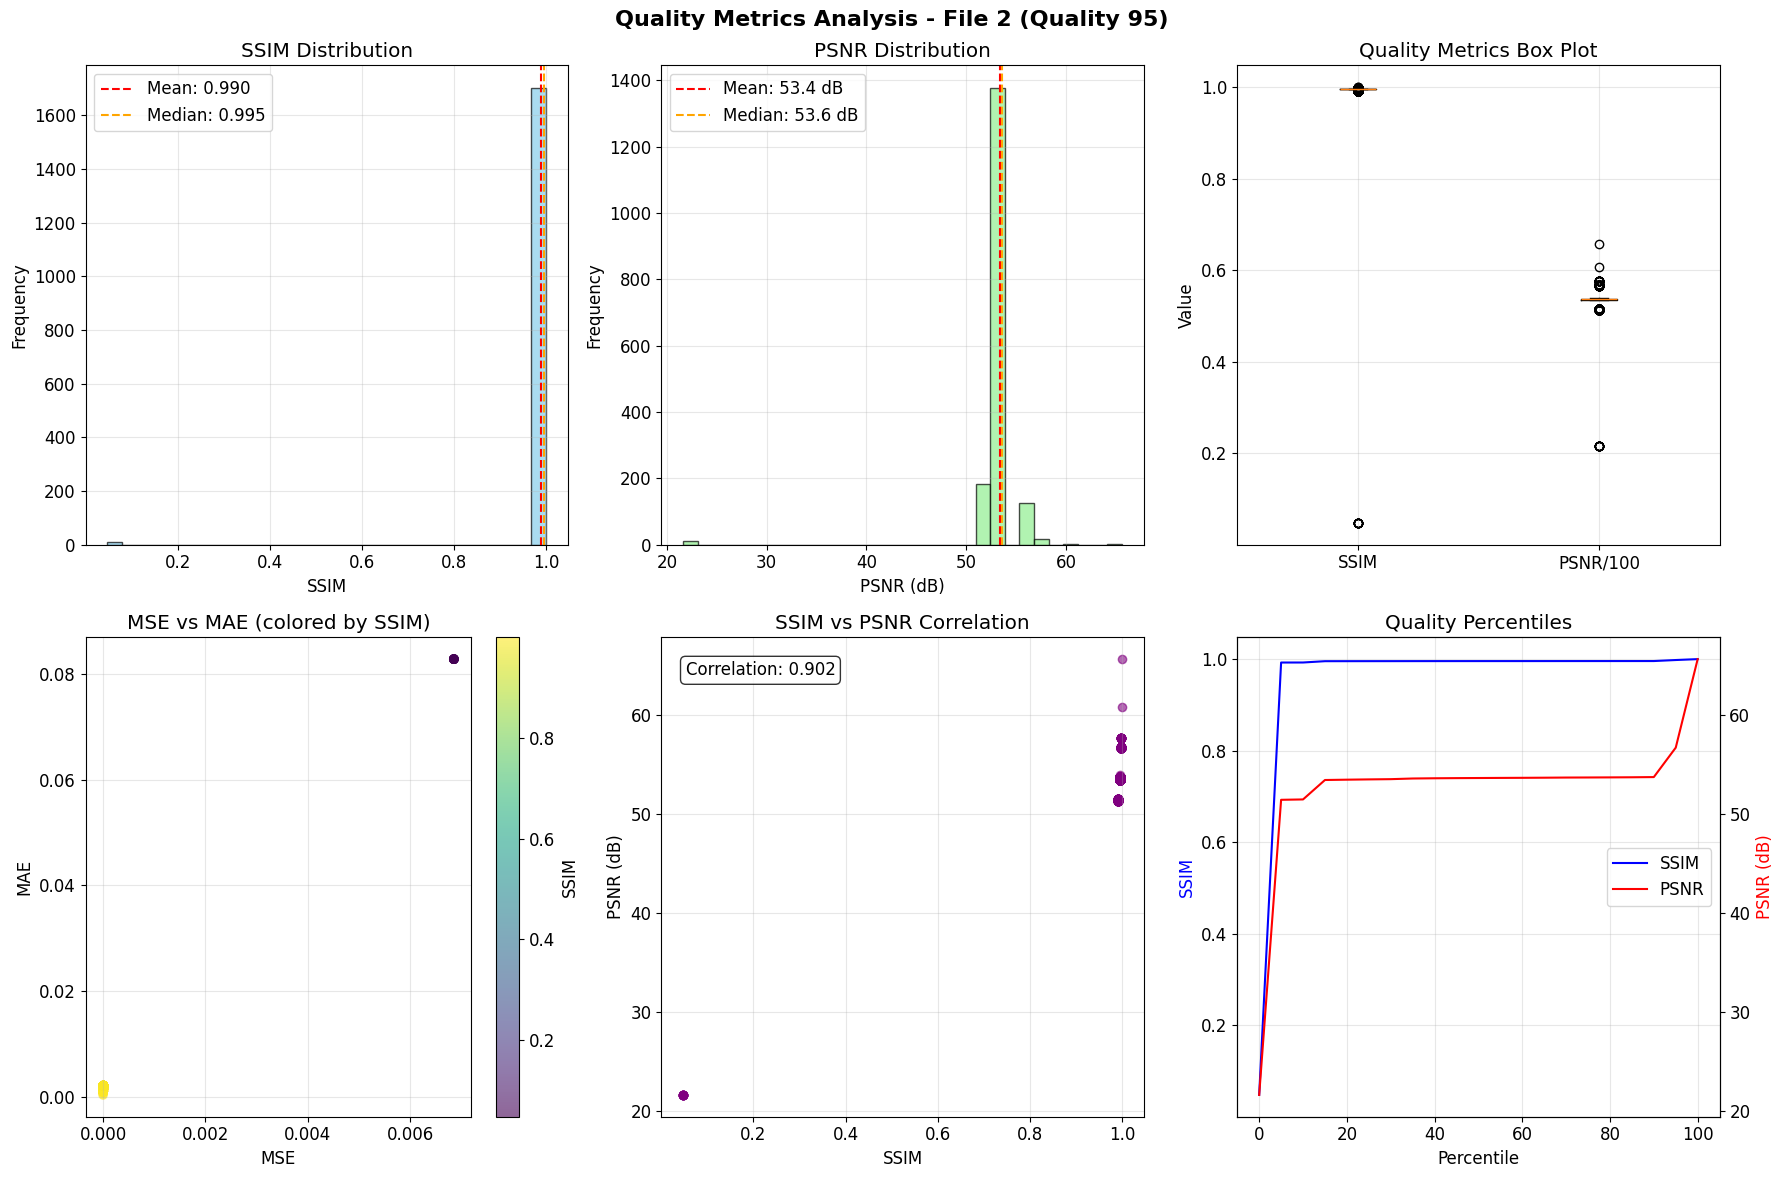


💾 Statistics summary saved to: comparison_results/file_2_q95/quality_statistics_file_2_q95.csv

🎯 Percentile Analysis:
--------------------
    1%: SSIM=0.9921, PSNR=51.29 dB
    5%: SSIM=0.9923, PSNR=51.41 dB
   10%: SSIM=0.9923, PSNR=51.45 dB
   25%: SSIM=0.9953, PSNR=53.47 dB
   50%: SSIM=0.9954, PSNR=53.61 dB
   75%: SSIM=0.9955, PSNR=53.66 dB
   90%: SSIM=0.9955, PSNR=53.70 dB
   95%: SSIM=0.9977, PSNR=56.67 dB
   99%: SSIM=0.9981, PSNR=57.52 dB

🔍 Quality Assessment:
--------------------
   SSIM Quality Distribution:
     Excellent (≥0.95): 1701/1711 (99.4%)
     Good (0.90-0.95):  0/1711 (0.0%)
     Fair (0.80-0.90):  0/1711 (0.0%)
     Poor (<0.80):      10/1711 (0.6%)

   PSNR Quality Distribution:
     Excellent (≥40 dB): 1701/1711 (99.4%)
     Good (30-40 dB):    0/1711 (0.0%)
     Fair (20-30 dB):    10/1711 (0.6%)
     Poor (<20 dB):      0/1711 (0.0%)


In [7]:
print("📊 Analyzing and Visualizing Quality Statistics")
print("=" * 50)

if not quality_results.empty:
    # Compute comprehensive statistics
    metrics = ['ssim', 'psnr', 'mse', 'mae']
    stats_summary = {}
    
    print("📈 Comprehensive Quality Statistics:")
    print("-" * 40)
    
    for metric in metrics:
        values = quality_results[metric]
        stats = {
            'mean': values.mean(),
            'median': values.median(),
            'std': values.std(),
            'min': values.min(),
            'max': values.max(),
            'q25': values.quantile(0.25),
            'q75': values.quantile(0.75),
            'iqr': values.quantile(0.75) - values.quantile(0.25)
        }
        stats_summary[metric] = stats
        
        print(f"\n{metric.upper()}:")
        print(f"   Mean: {stats['mean']:.4f}")
        print(f"   Median: {stats['median']:.4f}")
        print(f"   Std Dev: {stats['std']:.4f}")
        print(f"   Range: [{stats['min']:.4f}, {stats['max']:.4f}]")
        print(f"   IQR: {stats['iqr']:.4f} (Q25: {stats['q25']:.4f}, Q75: {stats['q75']:.4f})")
    
    # Create comprehensive visualization
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle(f'Quality Metrics Analysis - File {FILE_ID} (Quality {QUALITY})', 
                 fontsize=16, fontweight='bold')
    
    # SSIM histogram
    ax1 = axes[0, 0]
    ax1.hist(quality_results['ssim'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    ax1.axvline(stats_summary['ssim']['mean'], color='red', linestyle='--', 
                label=f"Mean: {stats_summary['ssim']['mean']:.3f}")
    ax1.axvline(stats_summary['ssim']['median'], color='orange', linestyle='--', 
                label=f"Median: {stats_summary['ssim']['median']:.3f}")
    ax1.set_xlabel('SSIM')
    ax1.set_ylabel('Frequency')
    ax1.set_title('SSIM Distribution')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # PSNR histogram
    ax2 = axes[0, 1]
    ax2.hist(quality_results['psnr'], bins=30, alpha=0.7, color='lightgreen', edgecolor='black')
    ax2.axvline(stats_summary['psnr']['mean'], color='red', linestyle='--', 
                label=f"Mean: {stats_summary['psnr']['mean']:.1f} dB")
    ax2.axvline(stats_summary['psnr']['median'], color='orange', linestyle='--', 
                label=f"Median: {stats_summary['psnr']['median']:.1f} dB")
    ax2.set_xlabel('PSNR (dB)')
    ax2.set_ylabel('Frequency')
    ax2.set_title('PSNR Distribution')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Box plots
    ax3 = axes[0, 2]
    box_data = [quality_results['ssim'], quality_results['psnr']/100]  # Scale PSNR for comparison
    ax3.boxplot(box_data, labels=['SSIM', 'PSNR/100'])
    ax3.set_title('Quality Metrics Box Plot')
    ax3.set_ylabel('Value')
    ax3.grid(True, alpha=0.3)
    
    # MSE vs MAE scatter
    ax4 = axes[1, 0]
    scatter = ax4.scatter(quality_results['mse'], quality_results['mae'], 
                         c=quality_results['ssim'], cmap='viridis', alpha=0.6)
    ax4.set_xlabel('MSE')
    ax4.set_ylabel('MAE')
    ax4.set_title('MSE vs MAE (colored by SSIM)')
    plt.colorbar(scatter, ax=ax4, label='SSIM')
    ax4.grid(True, alpha=0.3)
    
    # SSIM vs PSNR correlation
    ax5 = axes[1, 1]
    ax5.scatter(quality_results['ssim'], quality_results['psnr'], alpha=0.6, color='purple')
    ax5.set_xlabel('SSIM')
    ax5.set_ylabel('PSNR (dB)')
    ax5.set_title('SSIM vs PSNR Correlation')
    
    # Add correlation coefficient
    corr_coef = quality_results['ssim'].corr(quality_results['psnr'])
    ax5.text(0.05, 0.95, f'Correlation: {corr_coef:.3f}', 
             transform=ax5.transAxes, fontsize=12, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax5.grid(True, alpha=0.3)
    
    # Quality percentiles
    ax6 = axes[1, 2]
    percentiles = np.arange(0, 101, 5)
    ssim_pcts = [quality_results['ssim'].quantile(p/100) for p in percentiles]
    psnr_pcts = [quality_results['psnr'].quantile(p/100) for p in percentiles]
    
    ax6_twin = ax6.twinx()
    line1 = ax6.plot(percentiles, ssim_pcts, 'b-', label='SSIM')
    line2 = ax6_twin.plot(percentiles, psnr_pcts, 'r-', label='PSNR')
    
    ax6.set_xlabel('Percentile')
    ax6.set_ylabel('SSIM', color='b')
    ax6_twin.set_ylabel('PSNR (dB)', color='r')
    ax6.set_title('Quality Percentiles')
    ax6.grid(True, alpha=0.3)
    
    # Combine legends
    lines1, labels1 = ax6.get_legend_handles_labels()
    lines2, labels2 = ax6_twin.get_legend_handles_labels()
    ax6.legend(lines1 + lines2, labels1 + labels2, loc='center right')
    
    plt.tight_layout()
    plt.show()
    
    # Save statistics summary
    stats_df = pd.DataFrame(stats_summary).T
    stats_csv = OUTPUT_DIR / f'quality_statistics_file_{FILE_ID}_q{QUALITY}.csv'
    stats_df.to_csv(stats_csv)
    print(f"\n💾 Statistics summary saved to: {stats_csv}")
    
    # Print percentile analysis
    print(f"\n🎯 Percentile Analysis:")
    print("-" * 20)
    for pct in [1, 5, 10, 25, 50, 75, 90, 95, 99]:
        ssim_val = quality_results['ssim'].quantile(pct/100)
        psnr_val = quality_results['psnr'].quantile(pct/100)
        print(f"   {pct:2d}%: SSIM={ssim_val:.4f}, PSNR={psnr_val:.2f} dB")
    
    print(f"\n🔍 Quality Assessment:")
    print("-" * 20)
    
    # SSIM quality thresholds (typical values)
    excellent_ssim = (quality_results['ssim'] >= 0.95).sum()
    good_ssim = ((quality_results['ssim'] >= 0.90) & (quality_results['ssim'] < 0.95)).sum()
    fair_ssim = ((quality_results['ssim'] >= 0.80) & (quality_results['ssim'] < 0.90)).sum()
    poor_ssim = (quality_results['ssim'] < 0.80).sum()
    
    total_files = len(quality_results)
    print(f"   SSIM Quality Distribution:")
    print(f"     Excellent (≥0.95): {excellent_ssim}/{total_files} ({100*excellent_ssim/total_files:.1f}%)")
    print(f"     Good (0.90-0.95):  {good_ssim}/{total_files} ({100*good_ssim/total_files:.1f}%)")
    print(f"     Fair (0.80-0.90):  {fair_ssim}/{total_files} ({100*fair_ssim/total_files:.1f}%)")
    print(f"     Poor (<0.80):      {poor_ssim}/{total_files} ({100*poor_ssim/total_files:.1f}%)")
    
    # PSNR quality thresholds (typical values for images)
    excellent_psnr = (quality_results['psnr'] >= 40).sum()
    good_psnr = ((quality_results['psnr'] >= 30) & (quality_results['psnr'] < 40)).sum()
    fair_psnr = ((quality_results['psnr'] >= 20) & (quality_results['psnr'] < 30)).sum()
    poor_psnr = (quality_results['psnr'] < 20).sum()
    
    print(f"\n   PSNR Quality Distribution:")
    print(f"     Excellent (≥40 dB): {excellent_psnr}/{total_files} ({100*excellent_psnr/total_files:.1f}%)")
    print(f"     Good (30-40 dB):    {good_psnr}/{total_files} ({100*good_psnr/total_files:.1f}%)")
    print(f"     Fair (20-30 dB):    {fair_psnr}/{total_files} ({100*fair_psnr/total_files:.1f}%)")
    print(f"     Poor (<20 dB):      {poor_psnr}/{total_files} ({100*poor_psnr/total_files:.1f}%)")

else:
    print("❌ No quality results available for analysis")

## 7. Identify and Visualize Worst Performing Slices

🔍 Analyzing Worst Performing Slices
🔍 Identifying and Visualizing Worst 10 Slices
📊 Worst Performing Slices Summary:
----------------------------------------
    1. Index   7: SSIM=0.0478, PSNR=21.64 dB, File=PD1511_41_0008.tif
    2. Index   9: SSIM=0.0478, PSNR=21.64 dB, File=PD1511_41_0010.tif
    3. Index   6: SSIM=0.0478, PSNR=21.64 dB, File=PD1511_41_0007.tif
    4. Index   5: SSIM=0.0478, PSNR=21.64 dB, File=PD1511_41_0006.tif
    5. Index   8: SSIM=0.0478, PSNR=21.64 dB, File=PD1511_41_0009.tif
    6. Index   2: SSIM=0.0478, PSNR=21.64 dB, File=PD1511_41_0003.tif
    7. Index   4: SSIM=0.0478, PSNR=21.64 dB, File=PD1511_41_0005.tif
    8. Index   0: SSIM=0.0478, PSNR=21.64 dB, File=PD1511_41_0001.tif
    9. Index   1: SSIM=0.0478, PSNR=21.64 dB, File=PD1511_41_0002.tif
   10. Index   3: SSIM=0.0478, PSNR=21.64 dB, File=PD1511_41_0004.tif


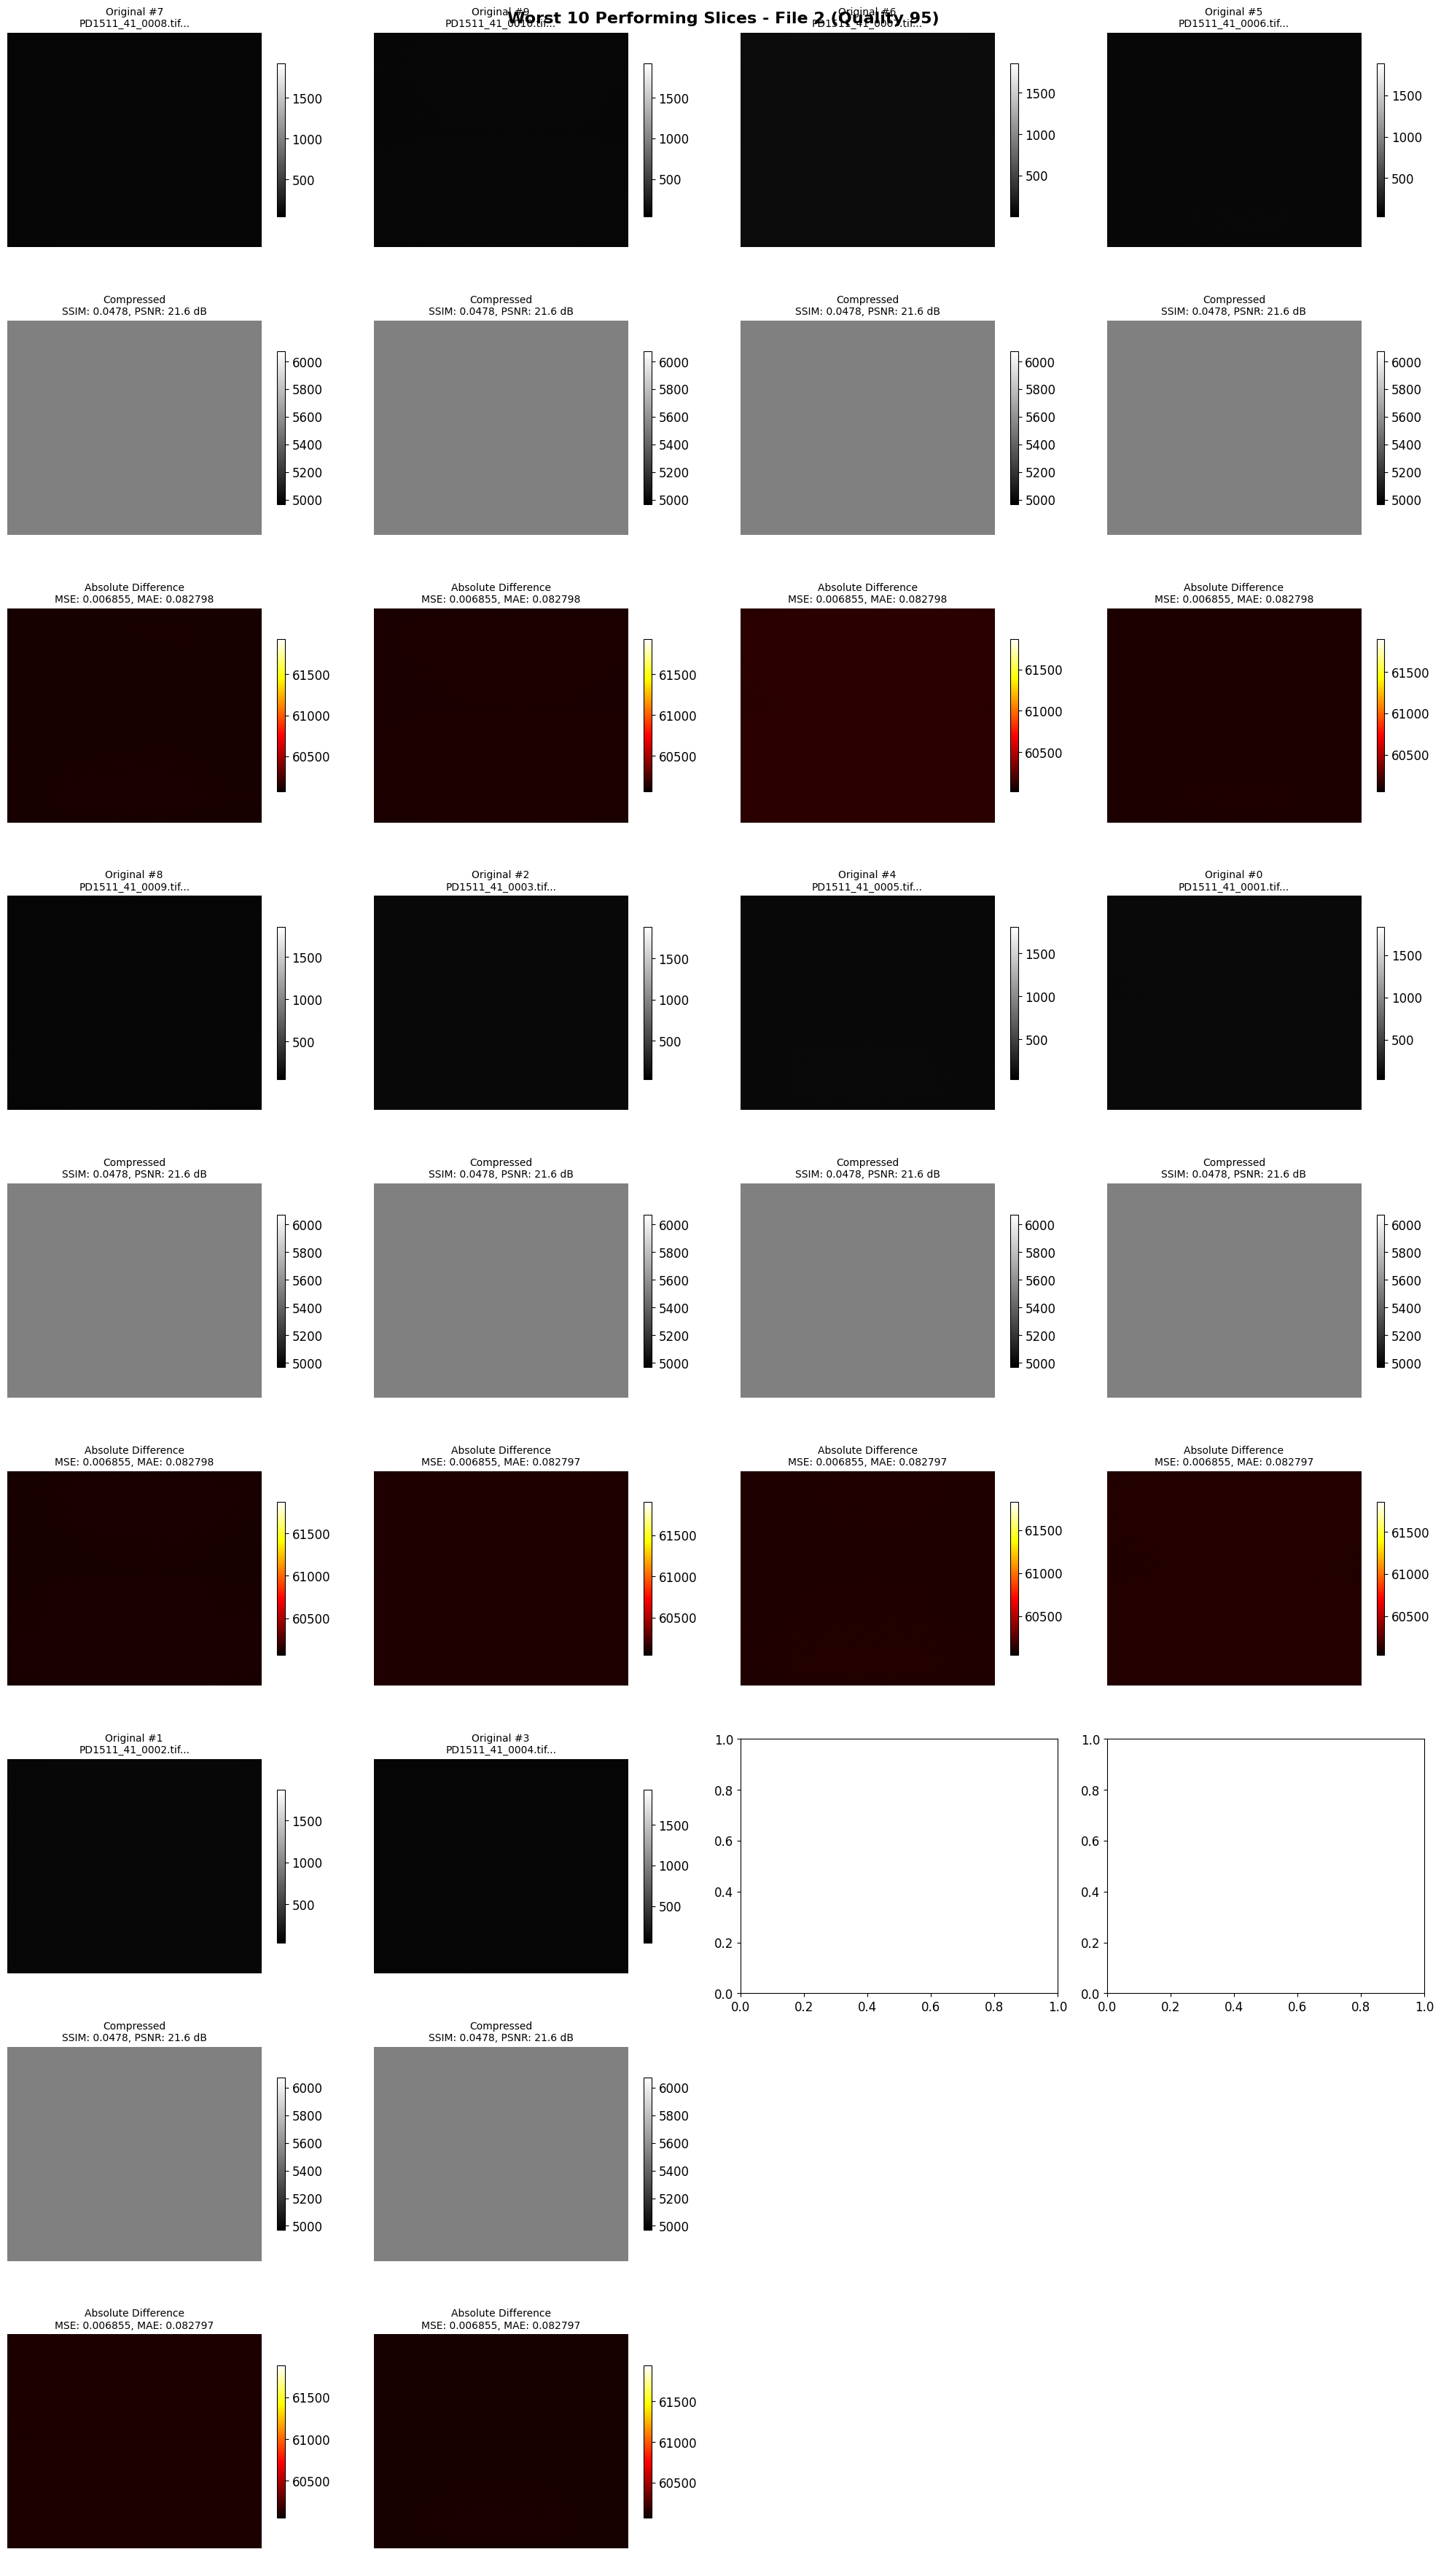


💾 Worst slices summary saved to: comparison_results/file_2_q95/worst_slices_file_2_q95.csv

📈 Worst Slices Analysis:
------------------------------
   Worst 10 slices average SSIM: 0.0478
   Overall average SSIM: 0.9897
   SSIM degradation: 95.2%

   Worst 10 slices average PSNR: 21.64 dB
   Overall average PSNR: 53.44 dB
   PSNR degradation: 31.80 dB

🔬 Worst Slices Characteristics:
-----------------------------------
   MSE range: [0.006855, 0.006855]
   MAE range: [0.082797, 0.082798]
   Original intensity mean: 0.001 ± 0.000
   Compressed intensity mean: 0.084 ± 0.000


In [8]:
def load_and_compare_images(original_path: Path, compressed_path: Path) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Load original and compressed images and compute difference map.
    
    Args:
        original_path: Path to original image
        compressed_path: Path to compressed image
        
    Returns:
        Tuple of (original_image, compressed_image, difference_map)
    """
    # Load images
    original_img = np.array(Image.open(original_path))
    compressed_img = np.array(Image.open(compressed_path))
    
    # Handle multi-channel images
    if original_img.ndim == 3:
        original_img = original_img[:, :, 0]
    if compressed_img.ndim == 3:
        compressed_img = compressed_img[:, :, 0]
    
    # Normalize for difference computation
    if original_img.dtype != compressed_img.dtype:
        original_img = original_img.astype(np.float64)
        compressed_img = compressed_img.astype(np.float64)
    
    # Compute difference map
    diff_map = np.abs(original_img - compressed_img)
    
    return original_img, compressed_img, diff_map


def visualize_worst_slices(quality_results: pd.DataFrame, num_worst: int = NUM_WORST_SLICES):
    """
    Identify and visualize the worst performing slices.
    
    Args:
        quality_results: DataFrame with quality metrics
        num_worst: Number of worst slices to visualize
    """
    print(f"🔍 Identifying and Visualizing Worst {num_worst} Slices")
    print("=" * 50)
    
    # Sort by SSIM (lower is worse) and PSNR (lower is worse)
    worst_ssim = quality_results.nsmallest(num_worst, 'ssim')
    worst_psnr = quality_results.nsmallest(num_worst, 'psnr')
    
    # Combine and get unique worst slices
    worst_indices = set(worst_ssim.index.tolist() + worst_psnr.index.tolist())
    worst_slices = quality_results.loc[list(worst_indices)].sort_values('ssim')
    
    print(f"📊 Worst Performing Slices Summary:")
    print("-" * 40)
    for i, (idx, row) in enumerate(worst_slices.head(num_worst).iterrows()):
        print(f"   {i+1:2d}. Index {row['index']:3d}: SSIM={row['ssim']:.4f}, "
              f"PSNR={row['psnr']:.2f} dB, File={row['original_file']}")
    
    # Visualize worst slices
    num_to_show = min(num_worst, len(worst_slices))
    cols = min(4, num_to_show)
    rows = (num_to_show + cols - 1) // cols
    
    fig, axes = plt.subplots(rows * 3, cols, figsize=(5*cols, 4*rows*3))
    if num_to_show == 1:
        axes = axes.reshape(-1, 1)
    elif rows == 1:
        axes = axes.reshape(3, -1)
    
    fig.suptitle(f'Worst {num_to_show} Performing Slices - File {FILE_ID} (Quality {QUALITY})', 
                 fontsize=16, fontweight='bold')
    
    for i, (idx, row) in enumerate(worst_slices.head(num_to_show).iterrows()):
        col = i % cols
        base_row = (i // cols) * 3
        
        try:
            # Load images
            original_path = original_files[row['index']]
            compressed_path = compressed_files[row['index']]
            original_img, compressed_img, diff_map = load_and_compare_images(original_path, compressed_path)
            
            # Original image
            if rows > 1:
                ax_orig = axes[base_row, col]
                ax_comp = axes[base_row + 1, col]
                ax_diff = axes[base_row + 2, col]
            else:
                ax_orig = axes[0, col]
                ax_comp = axes[1, col]
                ax_diff = axes[2, col]
            
            # Display original
            im1 = ax_orig.imshow(original_img, cmap='gray')
            ax_orig.set_title(f'Original #{row["index"]}\n{row["original_file"][:20]}...', fontsize=10)
            ax_orig.axis('off')
            plt.colorbar(im1, ax=ax_orig, shrink=0.6)
            
            # Display compressed
            im2 = ax_comp.imshow(compressed_img, cmap='gray')
            ax_comp.set_title(f'Compressed\nSSIM: {row["ssim"]:.4f}, PSNR: {row["psnr"]:.1f} dB', fontsize=10)
            ax_comp.axis('off')
            plt.colorbar(im2, ax=ax_comp, shrink=0.6)
            
            # Display difference
            im3 = ax_diff.imshow(diff_map, cmap='hot')
            ax_diff.set_title(f'Absolute Difference\nMSE: {row["mse"]:.6f}, MAE: {row["mae"]:.6f}', fontsize=10)
            ax_diff.axis('off')
            plt.colorbar(im3, ax=ax_diff, shrink=0.6)
            
        except Exception as e:
            print(f"   ⚠️  Error loading slice {row['index']}: {e}")
            
            # Show error message in plots
            for ax in [ax_orig, ax_comp, ax_diff]:
                ax.text(0.5, 0.5, f'Error loading\nslice {row["index"]}', 
                       ha='center', va='center', transform=ax.transAxes,
                       fontsize=12, color='red')
                ax.axis('off')
    
    # Hide unused subplots
    total_axes = rows * 3 * cols
    used_axes = num_to_show * 3
    if used_axes < total_axes:
        flat_axes = axes.flatten()
        for i in range(used_axes, total_axes):
            flat_axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Save worst slices summary
    worst_summary = worst_slices.head(num_worst)[['index', 'original_file', 'ssim', 'psnr', 'mse', 'mae']]
    worst_csv = OUTPUT_DIR / f'worst_slices_file_{FILE_ID}_q{QUALITY}.csv'
    worst_summary.to_csv(worst_csv, index=False)
    print(f"\n💾 Worst slices summary saved to: {worst_csv}")
    
    return worst_slices.head(num_worst)


print("🔍 Analyzing Worst Performing Slices")
print("=" * 50)

if not quality_results.empty:
    # Identify worst slices
    worst_slices_data = visualize_worst_slices(quality_results, NUM_WORST_SLICES)
    
    # Additional analysis of worst slices
    print(f"\n📈 Worst Slices Analysis:")
    print("-" * 30)
    
    worst_ssim_mean = worst_slices_data['ssim'].mean()
    worst_psnr_mean = worst_slices_data['psnr'].mean()
    overall_ssim_mean = quality_results['ssim'].mean()
    overall_psnr_mean = quality_results['psnr'].mean()
    
    print(f"   Worst {NUM_WORST_SLICES} slices average SSIM: {worst_ssim_mean:.4f}")
    print(f"   Overall average SSIM: {overall_ssim_mean:.4f}")
    print(f"   SSIM degradation: {((overall_ssim_mean - worst_ssim_mean) / overall_ssim_mean * 100):.1f}%")
    
    print(f"\n   Worst {NUM_WORST_SLICES} slices average PSNR: {worst_psnr_mean:.2f} dB")
    print(f"   Overall average PSNR: {overall_psnr_mean:.2f} dB")
    print(f"   PSNR degradation: {overall_psnr_mean - worst_psnr_mean:.2f} dB")
    
    # Check if worst slices have common characteristics
    print(f"\n🔬 Worst Slices Characteristics:")
    print("-" * 35)
    print(f"   MSE range: [{worst_slices_data['mse'].min():.6f}, {worst_slices_data['mse'].max():.6f}]")
    print(f"   MAE range: [{worst_slices_data['mae'].min():.6f}, {worst_slices_data['mae'].max():.6f}]")
    print(f"   Original intensity mean: {worst_slices_data['original_mean'].mean():.3f} ± {worst_slices_data['original_mean'].std():.3f}")
    print(f"   Compressed intensity mean: {worst_slices_data['compressed_mean'].mean():.3f} ± {worst_slices_data['compressed_mean'].std():.3f}")
    
else:
    print("❌ No quality results available for worst slice analysis")
    worst_slices_data = pd.DataFrame()

## 8. Generate Quality Metrics vs Slice Number Plots

📈 Generating Quality Metrics vs Slice Number Plots


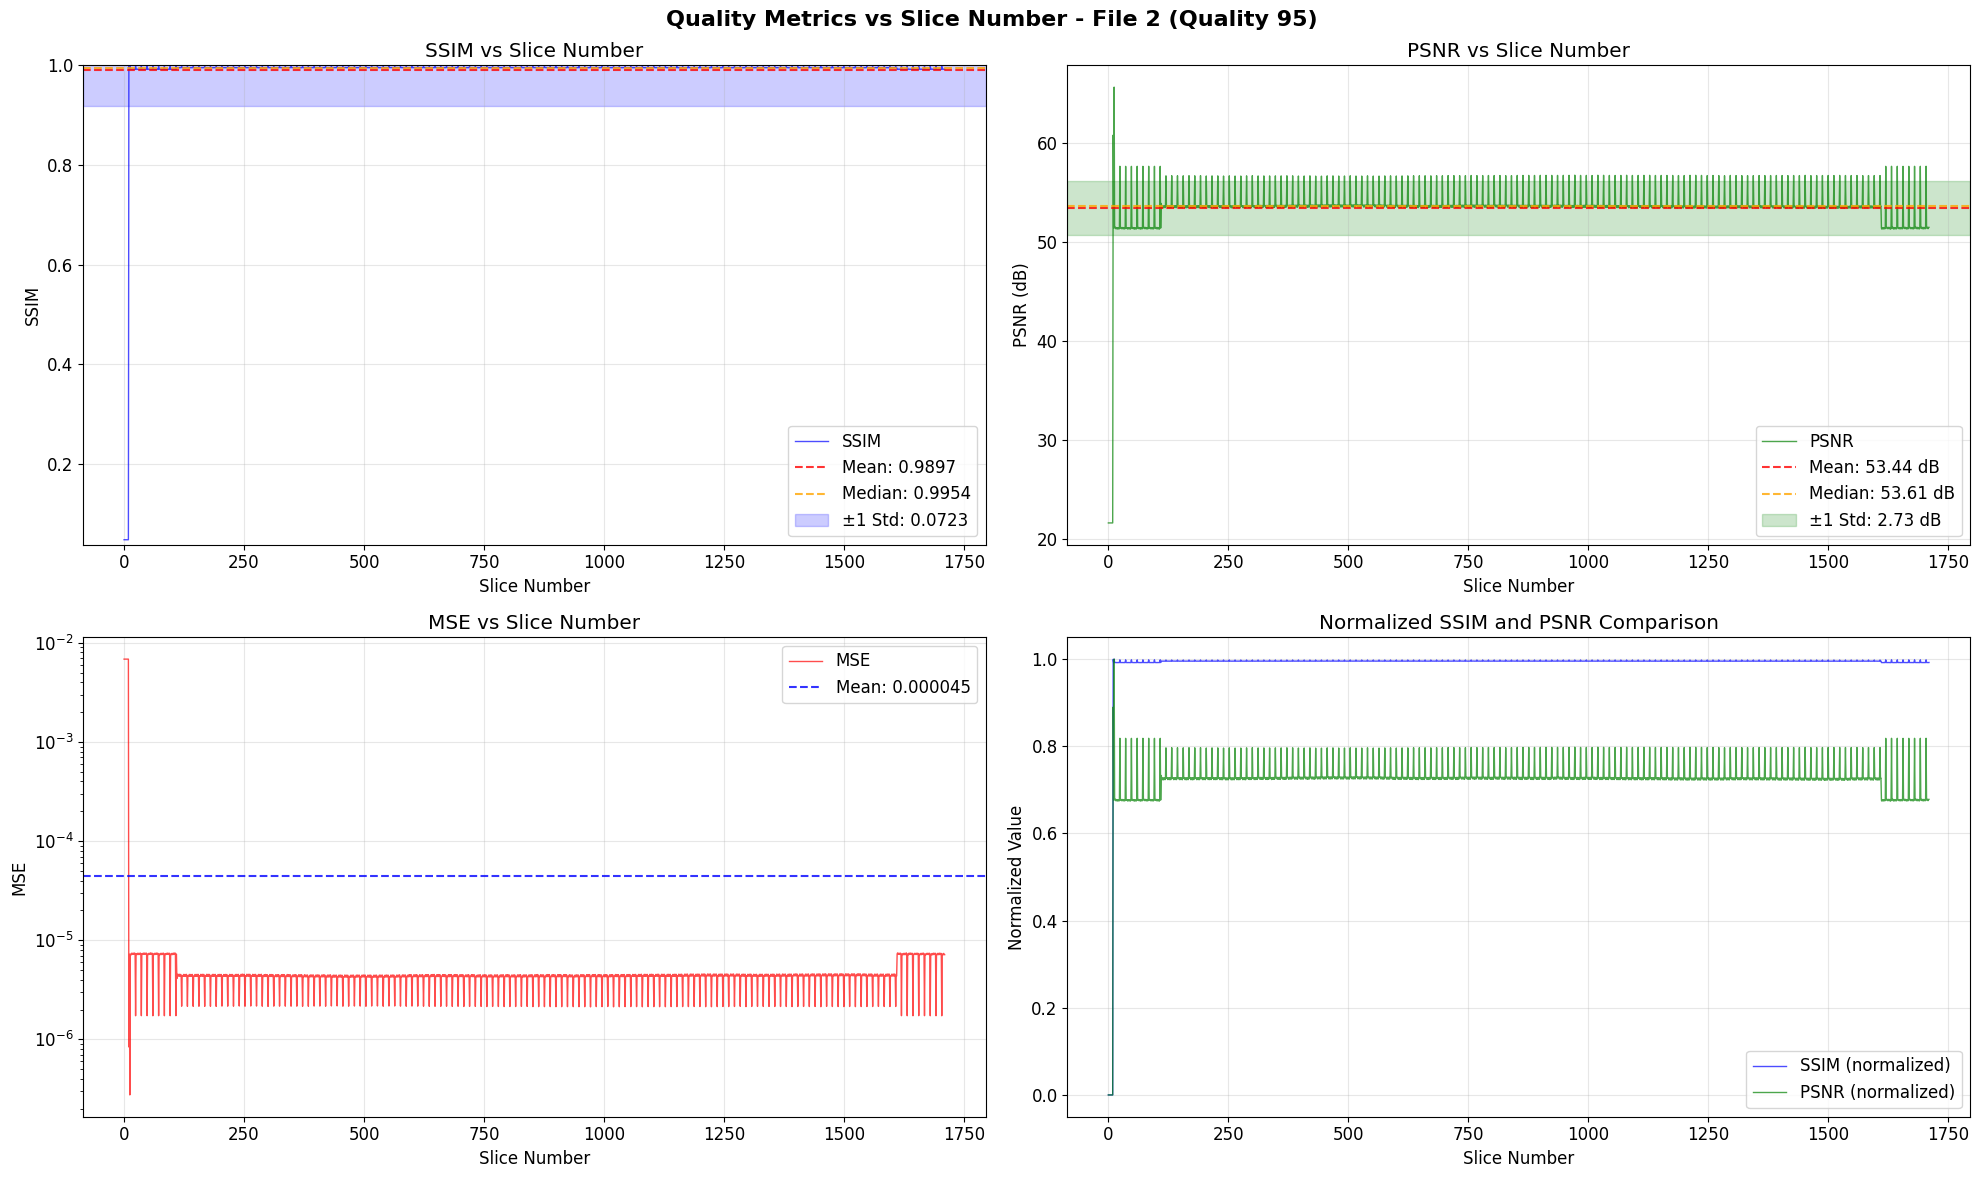


📊 Creating Moving Average Trends (window size: 85)


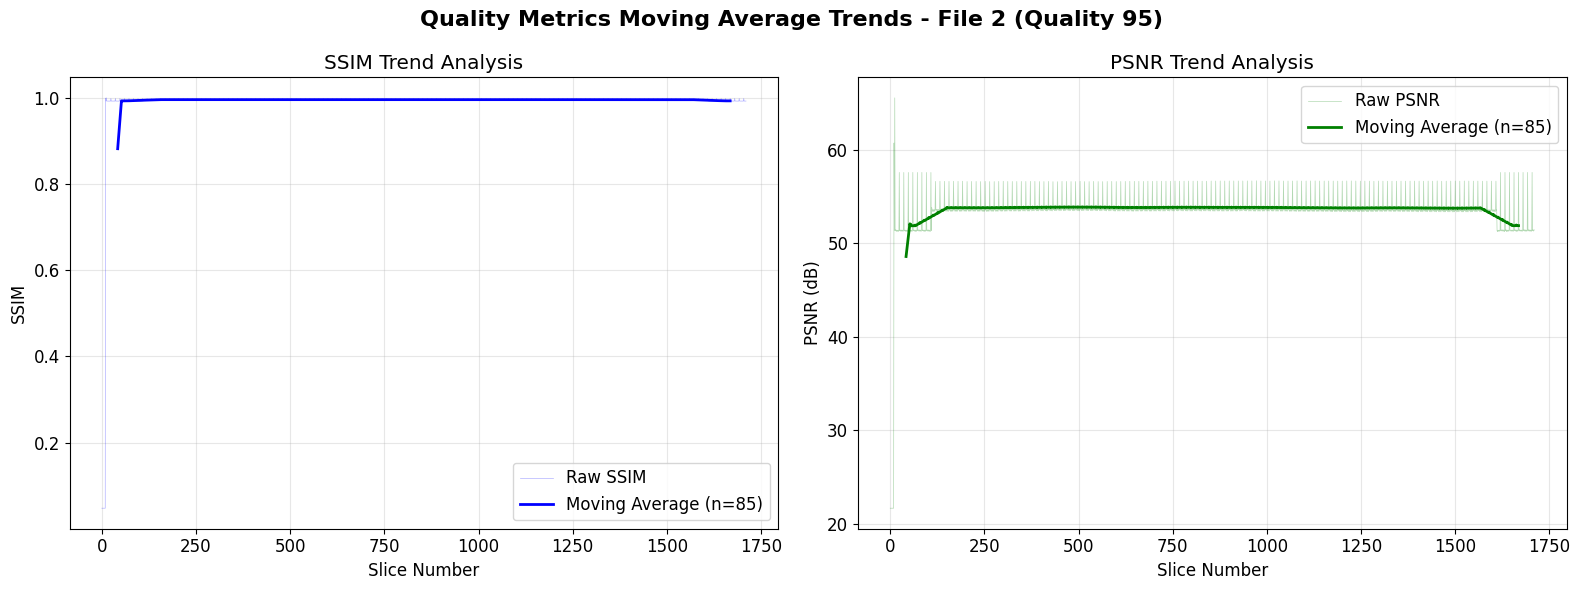


🔍 Quality Trend Analysis:
------------------------------
   Slices with SSIM < 0.8: 10 slices
     Slice numbers: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
   Large SSIM variations (>2σ): 1 locations
     Slice numbers: [10]
   Large PSNR variations (>2σ): 36 locations

💾 Quality trends data saved to: comparison_results/file_2_q95/quality_trends_file_2_q95.csv


In [9]:
print("📈 Generating Quality Metrics vs Slice Number Plots")
print("=" * 50)

if not quality_results.empty:
    # Sort by slice index for plotting
    plot_data = quality_results.sort_values('index').copy()
    
    # Create comprehensive quality trends visualization
    fig, axes = plt.subplots(2, 2, figsize=(20, 12))
    fig.suptitle(f'Quality Metrics vs Slice Number - File {FILE_ID} (Quality {QUALITY})', 
                 fontsize=16, fontweight='bold')
    
    # SSIM vs Slice Number
    ax1 = axes[0, 0]
    ax1.plot(plot_data['index'], plot_data['ssim'], 'b-', alpha=0.7, linewidth=1, label='SSIM')
    ax1.axhline(y=plot_data['ssim'].mean(), color='red', linestyle='--', alpha=0.8, 
                label=f'Mean: {plot_data["ssim"].mean():.4f}')
    ax1.axhline(y=plot_data['ssim'].median(), color='orange', linestyle='--', alpha=0.8,
                label=f'Median: {plot_data["ssim"].median():.4f}')
    
    # Add confidence bands
    ssim_mean = plot_data['ssim'].mean()
    ssim_std = plot_data['ssim'].std()
    ax1.axhspan(ssim_mean - ssim_std, ssim_mean + ssim_std, alpha=0.2, color='blue', 
                label=f'±1 Std: {ssim_std:.4f}')
    
    ax1.set_xlabel('Slice Number')
    ax1.set_ylabel('SSIM')
    ax1.set_title('SSIM vs Slice Number')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim([max(0, plot_data['ssim'].min() - 0.01), min(1, plot_data['ssim'].max() + 0.01)])
    
    # PSNR vs Slice Number
    ax2 = axes[0, 1]
    ax2.plot(plot_data['index'], plot_data['psnr'], 'g-', alpha=0.7, linewidth=1, label='PSNR')
    ax2.axhline(y=plot_data['psnr'].mean(), color='red', linestyle='--', alpha=0.8,
                label=f'Mean: {plot_data["psnr"].mean():.2f} dB')
    ax2.axhline(y=plot_data['psnr'].median(), color='orange', linestyle='--', alpha=0.8,
                label=f'Median: {plot_data["psnr"].median():.2f} dB')
    
    # Add confidence bands
    psnr_mean = plot_data['psnr'].mean()
    psnr_std = plot_data['psnr'].std()
    ax2.axhspan(psnr_mean - psnr_std, psnr_mean + psnr_std, alpha=0.2, color='green',
                label=f'±1 Std: {psnr_std:.2f} dB')
    
    ax2.set_xlabel('Slice Number')
    ax2.set_ylabel('PSNR (dB)')
    ax2.set_title('PSNR vs Slice Number')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # MSE vs Slice Number
    ax3 = axes[1, 0]
    ax3.plot(plot_data['index'], plot_data['mse'], 'r-', alpha=0.7, linewidth=1, label='MSE')
    ax3.axhline(y=plot_data['mse'].mean(), color='blue', linestyle='--', alpha=0.8,
                label=f'Mean: {plot_data["mse"].mean():.6f}')
    ax3.set_xlabel('Slice Number')
    ax3.set_ylabel('MSE')
    ax3.set_title('MSE vs Slice Number')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    ax3.set_yscale('log')  # Log scale for MSE
    
    # Combined SSIM and PSNR (normalized)
    ax4 = axes[1, 1]
    
    # Normalize SSIM and PSNR to [0, 1] for comparison
    ssim_norm = (plot_data['ssim'] - plot_data['ssim'].min()) / (plot_data['ssim'].max() - plot_data['ssim'].min())
    psnr_norm = (plot_data['psnr'] - plot_data['psnr'].min()) / (plot_data['psnr'].max() - plot_data['psnr'].min())
    
    ax4.plot(plot_data['index'], ssim_norm, 'b-', alpha=0.7, linewidth=1, label='SSIM (normalized)')
    ax4.plot(plot_data['index'], psnr_norm, 'g-', alpha=0.7, linewidth=1, label='PSNR (normalized)')
    
    ax4.set_xlabel('Slice Number')
    ax4.set_ylabel('Normalized Value')
    ax4.set_title('Normalized SSIM and PSNR Comparison')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Create moving average plots for trend analysis
    window_size = max(10, len(plot_data) // 20)  # Adaptive window size
    
    if len(plot_data) > window_size:
        print(f"\n📊 Creating Moving Average Trends (window size: {window_size})")
        
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        fig.suptitle(f'Quality Metrics Moving Average Trends - File {FILE_ID} (Quality {QUALITY})', 
                     fontsize=16, fontweight='bold')
        
        # Compute moving averages
        ssim_ma = plot_data['ssim'].rolling(window=window_size, center=True).mean()
        psnr_ma = plot_data['psnr'].rolling(window=window_size, center=True).mean()
        
        # SSIM moving average
        ax1 = axes[0]
        ax1.plot(plot_data['index'], plot_data['ssim'], 'b-', alpha=0.3, linewidth=0.5, label='Raw SSIM')
        ax1.plot(plot_data['index'], ssim_ma, 'b-', linewidth=2, label=f'Moving Average (n={window_size})')
        ax1.set_xlabel('Slice Number')
        ax1.set_ylabel('SSIM')
        ax1.set_title('SSIM Trend Analysis')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # PSNR moving average
        ax2 = axes[1]
        ax2.plot(plot_data['index'], plot_data['psnr'], 'g-', alpha=0.3, linewidth=0.5, label='Raw PSNR')
        ax2.plot(plot_data['index'], psnr_ma, 'g-', linewidth=2, label=f'Moving Average (n={window_size})')
        ax2.set_xlabel('Slice Number')
        ax2.set_ylabel('PSNR (dB)')
        ax2.set_title('PSNR Trend Analysis')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    # Identify problematic regions
    print(f"\n🔍 Quality Trend Analysis:")
    print("-" * 30)
    
    # Find slices below quality thresholds
    poor_ssim_slices = plot_data[plot_data['ssim'] < 0.8]['index'].tolist()
    poor_psnr_slices = plot_data[plot_data['psnr'] < 20]['index'].tolist()
    
    if poor_ssim_slices:
        print(f"   Slices with SSIM < 0.8: {len(poor_ssim_slices)} slices")
        if len(poor_ssim_slices) <= 10:
            print(f"     Slice numbers: {poor_ssim_slices}")
        else:
            print(f"     First 10: {poor_ssim_slices[:10]}...")
    
    if poor_psnr_slices:
        print(f"   Slices with PSNR < 20 dB: {len(poor_psnr_slices)} slices")
        if len(poor_psnr_slices) <= 10:
            print(f"     Slice numbers: {poor_psnr_slices}")
        else:
            print(f"     First 10: {poor_psnr_slices[:10]}...")
    
    # Detect large quality drops
    ssim_diff = plot_data['ssim'].diff().abs()
    psnr_diff = plot_data['psnr'].diff().abs()
    
    large_ssim_drops = plot_data[ssim_diff > 2 * ssim_diff.std()]['index'].tolist()
    large_psnr_drops = plot_data[psnr_diff > 2 * psnr_diff.std()]['index'].tolist()
    
    if large_ssim_drops:
        print(f"   Large SSIM variations (>2σ): {len(large_ssim_drops)} locations")
        if len(large_ssim_drops) <= 10:
            print(f"     Slice numbers: {large_ssim_drops}")
    
    if large_psnr_drops:
        print(f"   Large PSNR variations (>2σ): {len(large_psnr_drops)} locations")
        if len(large_psnr_drops) <= 10:
            print(f"     Slice numbers: {large_psnr_drops}")
    
    # Save trend data
    trend_data = plot_data[['index', 'ssim', 'psnr', 'mse', 'mae']].copy()
    trend_csv = OUTPUT_DIR / f'quality_trends_file_{FILE_ID}_q{QUALITY}.csv'
    trend_data.to_csv(trend_csv, index=False)
    print(f"\n💾 Quality trends data saved to: {trend_csv}")

else:
    print("❌ No quality results available for trend analysis")

## 9. Create Detailed Quality Assessment Report

In [10]:
print("📋 Creating Detailed Quality Assessment Report")
print("=" * 50)

if not quality_results.empty:
    from datetime import datetime
    
    # Generate comprehensive report
    report_timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    
    report_content = f"""
TIFF Compression Quality Assessment Report
==========================================

Generated: {report_timestamp}
Dataset: File {FILE_ID} with Quality {QUALITY}
Original Path: {ORIGINAL_PATH}
Compressed Path: {COMPRESSED_PATH}

PROCESSING SUMMARY
------------------
Total Files Analyzed: {len(quality_results)}
Processing Time: {total_time:.1f} seconds
Average Time per File: {total_time/len(quality_results):.3f} seconds
Parallel Workers Used: {MAX_WORKERS}
Success Rate: {len(quality_results)/len(all_results)*100:.1f}%

IMAGE SPECIFICATIONS
--------------------
Image Dimensions: {image_shape}
Data Types: {validation_info['typical_dtypes']}
File Format: TIFF

QUALITY METRICS SUMMARY
-----------------------
SSIM (Structural Similarity Index):
  Mean: {stats_summary['ssim']['mean']:.6f}
  Median: {stats_summary['ssim']['median']:.6f}
  Standard Deviation: {stats_summary['ssim']['std']:.6f}
  Range: [{stats_summary['ssim']['min']:.6f}, {stats_summary['ssim']['max']:.6f}]
  IQR: {stats_summary['ssim']['iqr']:.6f}

PSNR (Peak Signal-to-Noise Ratio):
  Mean: {stats_summary['psnr']['mean']:.3f} dB
  Median: {stats_summary['psnr']['median']:.3f} dB
  Standard Deviation: {stats_summary['psnr']['std']:.3f} dB
  Range: [{stats_summary['psnr']['min']:.3f}, {stats_summary['psnr']['max']:.3f}] dB
  IQR: {stats_summary['psnr']['iqr']:.3f} dB

MSE (Mean Squared Error):
  Mean: {stats_summary['mse']['mean']:.8f}
  Median: {stats_summary['mse']['median']:.8f}
  Standard Deviation: {stats_summary['mse']['std']:.8f}
  Range: [{stats_summary['mse']['min']:.8f}, {stats_summary['mse']['max']:.8f}]

MAE (Mean Absolute Error):
  Mean: {stats_summary['mae']['mean']:.8f}
  Median: {stats_summary['mae']['median']:.8f}
  Standard Deviation: {stats_summary['mae']['std']:.8f}
  Range: [{stats_summary['mae']['min']:.8f}, {stats_summary['mae']['max']:.8f}]

QUALITY DISTRIBUTION ANALYSIS
------------------------------
SSIM Quality Categories:
  Excellent (≥0.95): {excellent_ssim}/{total_files} ({100*excellent_ssim/total_files:.1f}%)
  Good (0.90-0.95): {good_ssim}/{total_files} ({100*good_ssim/total_files:.1f}%)
  Fair (0.80-0.90): {fair_ssim}/{total_files} ({100*fair_ssim/total_files:.1f}%)
  Poor (<0.80): {poor_ssim}/{total_files} ({100*poor_ssim/total_files:.1f}%)

PSNR Quality Categories:
  Excellent (≥40 dB): {excellent_psnr}/{total_files} ({100*excellent_psnr/total_files:.1f}%)
  Good (30-40 dB): {good_psnr}/{total_files} ({100*good_psnr/total_files:.1f}%)
  Fair (20-30 dB): {fair_psnr}/{total_files} ({100*fair_psnr/total_files:.1f}%)
  Poor (<20 dB): {poor_psnr}/{total_files} ({100*poor_psnr/total_files:.1f}%)

PERCENTILE ANALYSIS
-------------------"""
    
    # Add percentiles
    for pct in [1, 5, 10, 25, 50, 75, 90, 95, 99]:
        ssim_val = quality_results['ssim'].quantile(pct/100)
        psnr_val = quality_results['psnr'].quantile(pct/100)
        report_content += f"\n{pct:2d}th Percentile: SSIM={ssim_val:.6f}, PSNR={psnr_val:.3f} dB"
    
    # Add worst slices information
    if not worst_slices_data.empty:
        report_content += f"""

WORST PERFORMING SLICES
-----------------------
Number of Worst Slices Analyzed: {len(worst_slices_data)}
Worst SSIM: {worst_slices_data['ssim'].min():.6f} (Slice {worst_slices_data.loc[worst_slices_data['ssim'].idxmin(), 'index']})
Worst PSNR: {worst_slices_data['psnr'].min():.3f} dB (Slice {worst_slices_data.loc[worst_slices_data['psnr'].idxmin(), 'index']})

Average Quality Degradation in Worst Slices:
  SSIM degradation: {((overall_ssim_mean - worst_ssim_mean) / overall_ssim_mean * 100):.1f}%
  PSNR degradation: {overall_psnr_mean - worst_psnr_mean:.3f} dB

Top 10 Worst Slices by SSIM:"""
        
        for i, (idx, row) in enumerate(worst_slices_data.head(10).iterrows()):
            report_content += f"\n  {i+1:2d}. Slice {row['index']:3d}: SSIM={row['ssim']:.6f}, PSNR={row['psnr']:.2f} dB ({row['original_file']})"
    
    # Add correlation analysis
    ssim_psnr_corr = quality_results['ssim'].corr(quality_results['psnr'])
    ssim_mse_corr = quality_results['ssim'].corr(quality_results['mse'])
    psnr_mse_corr = quality_results['psnr'].corr(quality_results['mse'])
    
    report_content += f"""

CORRELATION ANALYSIS
--------------------
SSIM vs PSNR Correlation: {ssim_psnr_corr:.4f}
SSIM vs MSE Correlation: {ssim_mse_corr:.4f}
PSNR vs MSE Correlation: {psnr_mse_corr:.4f}

COMPRESSION QUALITY ASSESSMENT
------------------------------"""
    
    # Overall quality assessment
    if stats_summary['ssim']['mean'] >= 0.95:
        overall_quality = "EXCELLENT"
    elif stats_summary['ssim']['mean'] >= 0.90:
        overall_quality = "GOOD"
    elif stats_summary['ssim']['mean'] >= 0.80:
        overall_quality = "FAIR"
    else:
        overall_quality = "POOR"
    
    report_content += f"""
Overall Compression Quality: {overall_quality}

Quality Indicators:
  - Average SSIM of {stats_summary['ssim']['mean']:.4f} indicates {overall_quality.lower()} structural preservation
  - Average PSNR of {stats_summary['psnr']['mean']:.2f} dB indicates {'excellent' if stats_summary['psnr']['mean'] >= 40 else 'good' if stats_summary['psnr']['mean'] >= 30 else 'fair' if stats_summary['psnr']['mean'] >= 20 else 'poor'} signal quality
  - {100*excellent_ssim/total_files:.1f}% of slices achieve excellent SSIM (≥0.95)
  - {100*(excellent_ssim + good_ssim)/total_files:.1f}% of slices achieve good or better SSIM (≥0.90)

RECOMMENDATIONS
---------------"""
    
    # Add recommendations based on quality
    if overall_quality == "EXCELLENT":
        report_content += """
✅ The compression quality is excellent with minimal loss of structural information.
✅ Current quality setting ({}) is well-suited for this dataset.
✅ No significant quality issues detected.""".format(QUALITY)
    elif overall_quality == "GOOD":
        report_content += """
✅ The compression quality is good with acceptable structural preservation.
⚠️  Consider monitoring the {}% of slices with fair or poor quality.
💡 Current quality setting ({}) provides good balance of compression and quality.""".format(100*fair_ssim/total_files + 100*poor_ssim/total_files, QUALITY)
    elif overall_quality == "FAIR":
        report_content += """
⚠️  The compression quality is fair with noticeable quality degradation.
⚠️  {}% of slices have poor SSIM (<0.80) - consider investigating these slices.
💡 Consider increasing compression quality setting for better results.""".format(100*poor_ssim/total_files)
    else:
        report_content += """
❌ The compression quality is poor with significant quality loss.
❌ {}% of slices have unacceptable quality - compression settings need adjustment.
🚨 Strongly recommend increasing quality setting or using lossless compression.""".format(100*poor_ssim/total_files)
    
    report_content += f"""

FILES GENERATED
---------------
Quality Metrics: {OUTPUT_DIR / f'quality_metrics_file_{FILE_ID}_q{QUALITY}.csv'}
Statistics Summary: {OUTPUT_DIR / f'quality_statistics_file_{FILE_ID}_q{QUALITY}.csv'}
Worst Slices: {OUTPUT_DIR / f'worst_slices_file_{FILE_ID}_q{QUALITY}.csv'}
Quality Trends: {OUTPUT_DIR / f'quality_trends_file_{FILE_ID}_q{QUALITY}.csv'}
This Report: {OUTPUT_DIR / f'quality_assessment_report_file_{FILE_ID}_q{QUALITY}.txt'}

ANALYSIS CONFIGURATION
----------------------
Number of Worst Slices Analyzed: {NUM_WORST_SLICES}
Parallel Workers: {MAX_WORKERS}
Batch Size: {BATCH_SIZE}
Chunk Size: {CHUNK_SIZE}

Report generated by TIFF Compression Quality Comparison Notebook
================================================================
"""
    
    # Save report
    report_file = OUTPUT_DIR / f'quality_assessment_report_file_{FILE_ID}_q{QUALITY}.txt'
    with open(report_file, 'w') as f:
        f.write(report_content)
    
    print(f"✅ Comprehensive quality assessment report generated!")
    print(f"📄 Report saved to: {report_file}")
    
    # Display key findings
    print(f"\n🎯 Key Findings Summary:")
    print("-" * 25)
    print(f"   Overall Quality: {overall_quality}")
    print(f"   Average SSIM: {stats_summary['ssim']['mean']:.4f}")
    print(f"   Average PSNR: {stats_summary['psnr']['mean']:.2f} dB")
    print(f"   Excellent Quality Slices: {100*excellent_ssim/total_files:.1f}%")
    print(f"   Poor Quality Slices: {100*poor_ssim/total_files:.1f}%")
    print(f"   SSIM-PSNR Correlation: {ssim_psnr_corr:.3f}")
    
    # Final recommendation
    print(f"\n💡 Recommendation:")
    if overall_quality in ["EXCELLENT", "GOOD"]:
        print(f"   ✅ Quality {QUALITY} setting is {overall_quality.lower()} for this dataset")
    else:
        print(f"   ⚠️  Consider increasing quality setting - current results are {overall_quality.lower()}")
    
    print(f"\n📁 All results saved to: {OUTPUT_DIR}")
    
else:
    print("❌ No quality results available for report generation")

print(f"\n🎉 TIFF Compression Quality Comparison Analysis Complete!")
print("=" * 60)

📋 Creating Detailed Quality Assessment Report
✅ Comprehensive quality assessment report generated!
📄 Report saved to: comparison_results/file_2_q95/quality_assessment_report_file_2_q95.txt

🎯 Key Findings Summary:
-------------------------
   Overall Quality: EXCELLENT
   Average SSIM: 0.9897
   Average PSNR: 53.44 dB
   Excellent Quality Slices: 99.4%
   Poor Quality Slices: 0.6%
   SSIM-PSNR Correlation: 0.902

💡 Recommendation:
   ✅ Quality 95 setting is excellent for this dataset

📁 All results saved to: comparison_results/file_2_q95

🎉 TIFF Compression Quality Comparison Analysis Complete!
